## Import necessary libraries

In [5]:
import math
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression , Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split,RandomizedSearchCV

## Importing data into notebook

In [6]:
df = pd.read_excel('Premium_rest.xlsx')
print(df.shape)
df.head()

(29904, 14)


,Unnamed: 0,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,5,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [7]:
df['Genetical_Risk'] = 1

## Data cleaning - Checking for null values and duplicates

In [8]:
df.isna().sum()

Unnamed: 0               0
Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           9
Employment_Status        1
Income_Level             9
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
Genetical_Risk           0
dtype: int64

In [9]:
df.dropna(inplace=True)
df.isna().sum()

Unnamed: 0               0
Age                      0
Gender                   0
Region                   0
Marital_status           0
Number Of Dependants     0
BMI_Category             0
Smoking_Status           0
Employment_Status        0
Income_Level             0
Income_Lakhs             0
Medical History          0
Insurance_Plan           0
Annual_Premium_Amount    0
Genetical_Risk           0
dtype: int64

In [10]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## Converting column names to snake case

In [11]:
df.columns = df.columns.str.replace(' ','_').str.lower()
df.head(1)

,unnamed:_0,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,1


## Quick statistics of numerical columns 

In [12]:
df.describe()

,unnamed:_0,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,25027.094091,43.396105,2.379910,23.364184,20892.303821,1.0
std,14432.632929,13.412657,1.431201,24.740339,6936.813440,0.0
min,0.000000,26.000000,-3.000000,1.000000,3625.000000,1.0
25%,12599.250000,34.000000,1.000000,7.000000,15697.250000,1.0
50%,25067.500000,42.000000,3.000000,17.000000,20489.000000,1.0
75%,37563.750000,52.000000,3.000000,32.000000,26360.000000,1.0
max,49999.000000,356.000000,5.000000,930.000000,43471.000000,1.0


From the above statistics of numerical values we can clearly see some outliers in the data for eg in the age section the max age is 356 which is clearly an outlier and in number_of_depedants we can see negative values and in income_lakhs this might be outlier or it is true but the value will make the data right skewed and it will cause in change in mean value from its actual value

## Treating outlier in age column

In [13]:
# lets consider age threshold as 100 
df[df.age>100].shape
df1 = df[df.age<100].copy()
df1.describe()

,unnamed:_0,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29828.000000,29828.000000,29828.000000,29828.000000,29828.000000,29828.0
mean,25028.882091,43.095380,2.381755,23.371530,20901.900563,1.0
std,14431.843528,11.041991,1.430735,24.751262,6928.457636,0.0
min,0.000000,26.000000,-3.000000,1.000000,6538.000000,1.0
25%,12599.750000,34.000000,1.000000,7.000000,15706.000000,1.0
50%,25068.500000,42.000000,3.000000,17.000000,20496.000000,1.0
75%,37564.500000,52.000000,3.000000,32.000000,26361.000000,1.0
max,49999.000000,72.000000,5.000000,930.000000,43471.000000,1.0


## Treating outlier in number_of_dependencies column

In [14]:
# lets consider number_of_dependants threshold as abs of values 
df1[df1.number_of_dependants<0].shape
df1.number_of_dependants = abs(df1.number_of_dependants)
df1.describe()

,unnamed:_0,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29828.000000,29828.000000,29828.000000,29828.000000,29828.000000,29828.0
mean,25028.882091,43.095380,2.387790,23.371530,20901.900563,1.0
std,14431.843528,11.041991,1.420641,24.751262,6928.457636,0.0
min,0.000000,26.000000,0.000000,1.000000,6538.000000,1.0
25%,12599.750000,34.000000,1.000000,7.000000,15706.000000,1.0
50%,25068.500000,42.000000,3.000000,17.000000,20496.000000,1.0
75%,37564.500000,52.000000,3.000000,32.000000,26361.000000,1.0
max,49999.000000,72.000000,5.000000,930.000000,43471.000000,1.0


## Treating outlier in income_lakhs column

In [15]:
Q1,Q3 = df.income_lakhs.quantile([0.25,0.85])
IQR = Q3-Q1
lower_bound = Q1-2*IQR
upper_bount = Q3+2*IQR
lower_bound,upper_bount

(-59.0, 106.0)

In [16]:
df2 = df1[df1.income_lakhs<upper_bount].copy()
df2.describe()

,unnamed:_0,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29822.000000,29822.000000,29822.000000,29822.000000,29822.000000,29822.0
mean,25030.357152,43.094896,2.387734,23.226343,20900.689223,1.0
std,14431.397026,11.042430,1.420644,22.455408,6928.192115,0.0
min,0.000000,26.000000,0.000000,1.000000,6538.000000,1.0
25%,12605.250000,34.000000,1.000000,7.000000,15705.250000,1.0
50%,25070.000000,42.000000,3.000000,17.000000,20495.500000,1.0
75%,37565.500000,52.000000,3.000000,32.000000,26360.000000,1.0
max,49999.000000,72.000000,5.000000,100.000000,43471.000000,1.0


In [17]:
df2.shape

(29822, 15)

## Plotting Boxplot for checking for outliers if any

In [18]:
features = df.select_dtypes(include=['float64', 'int64']).columns
features

Index(['unnamed:_0', 'age', 'number_of_dependants', 'income_lakhs',
       'annual_premium_amount', 'genetical_risk'],
      dtype='str')

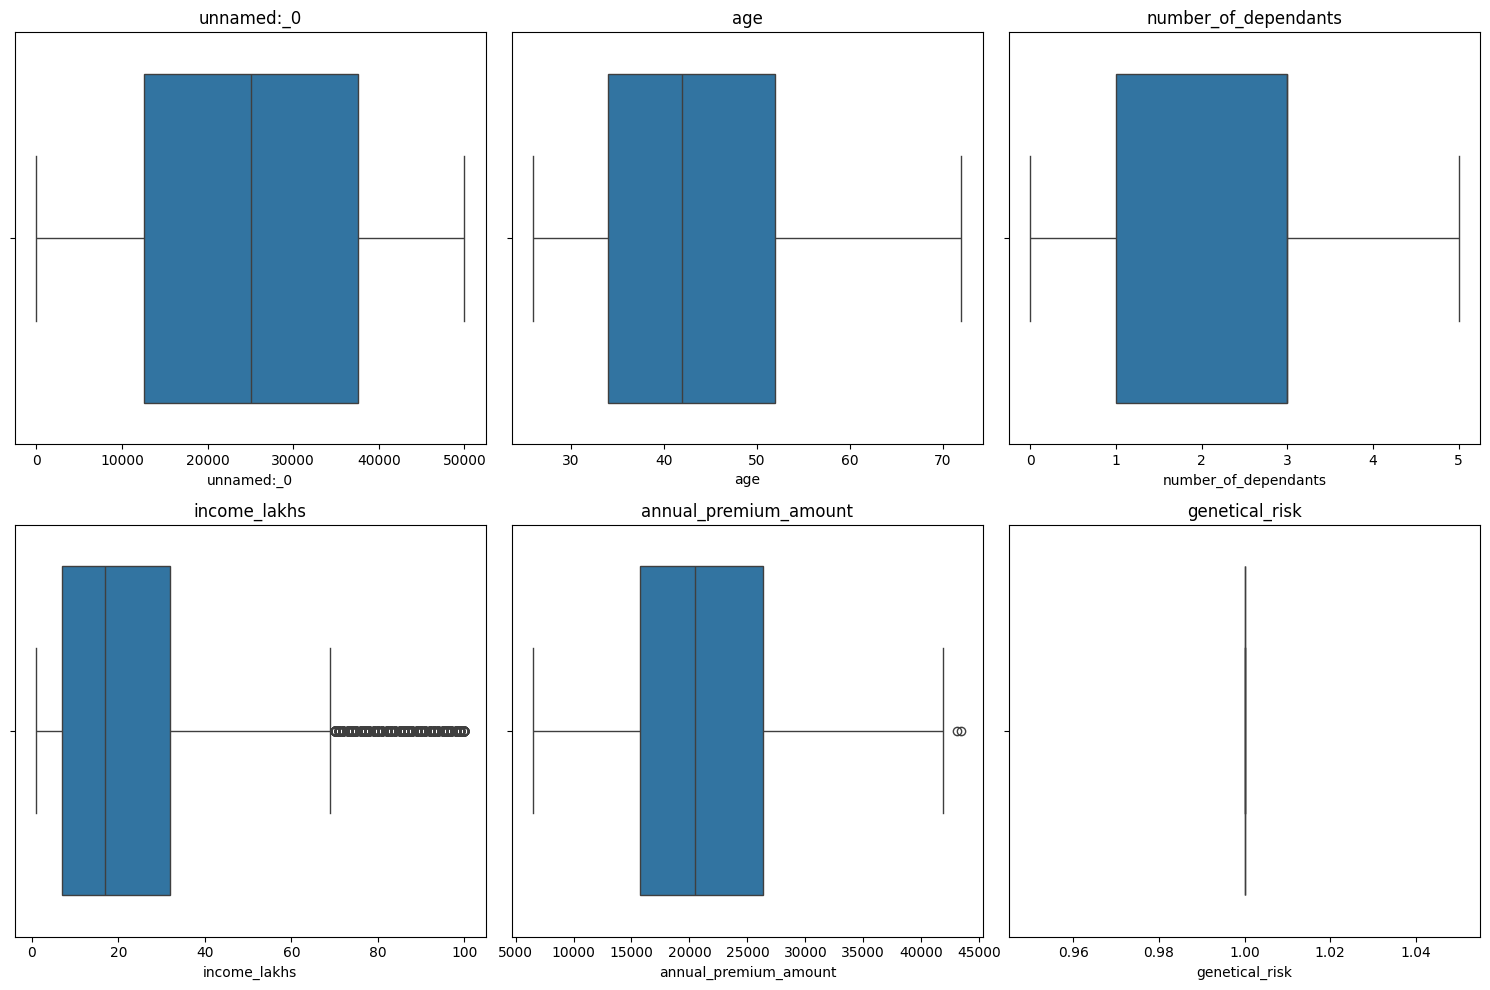

In [19]:
n = len(features)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
axes = axes.flatten()  # flatten in case of multiple rows

for i, feature in enumerate(features):
    sns.boxplot(x=df2[feature], ax=axes[i])
    axes[i].set_title(feature)

# Remove empty subplots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Plotting Scatter plot for checking patterns in data points

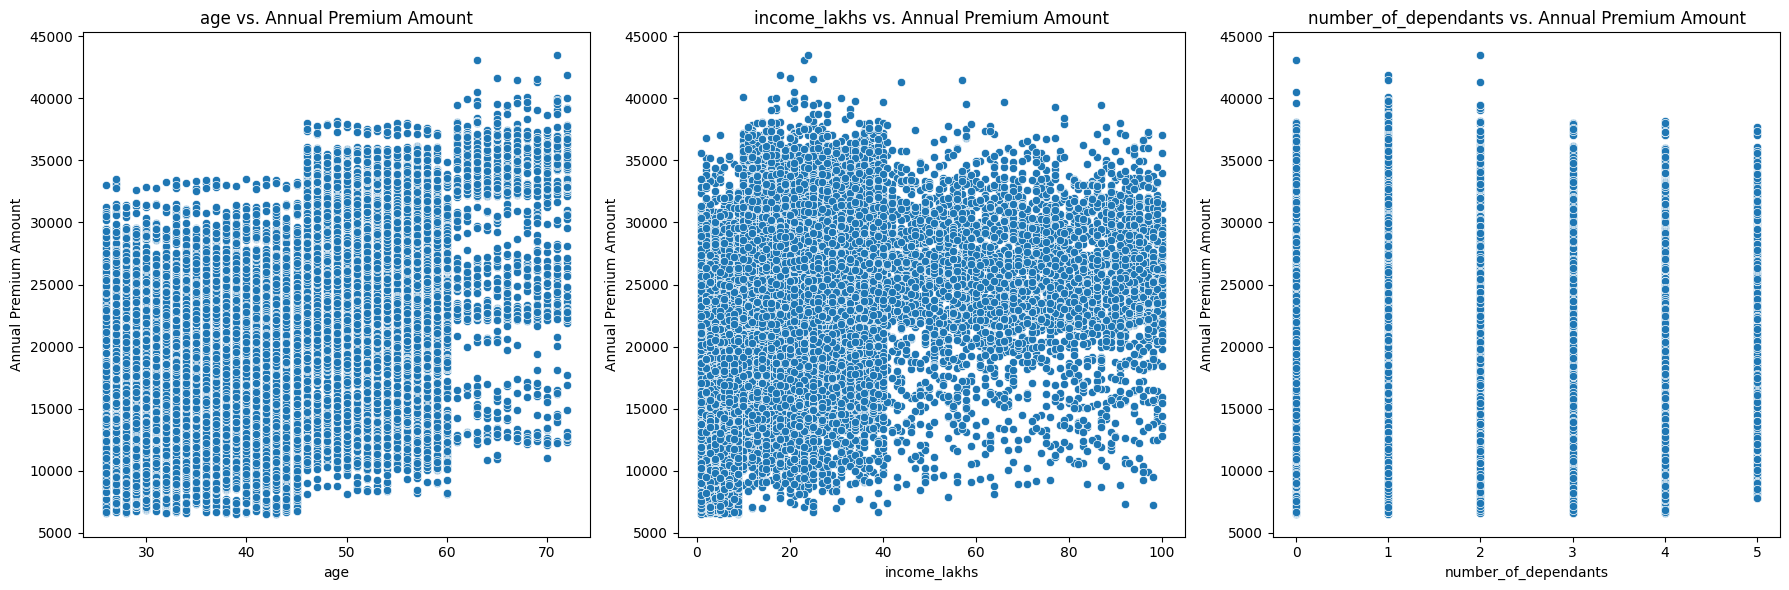

In [20]:
numeric_features = ['age', 'income_lakhs', 'number_of_dependants']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_features):
    sns.scatterplot(x=df2[column], y=df2['annual_premium_amount'], ax=ax)
    ax.set_title(f'{column} vs. Annual Premium Amount')
    ax.set_xlabel(column)
    ax.set_ylabel('Annual Premium Amount')

plt.tight_layout()  # Adjust layout
plt.show()

## Plotting histogram for checking patterns in data points

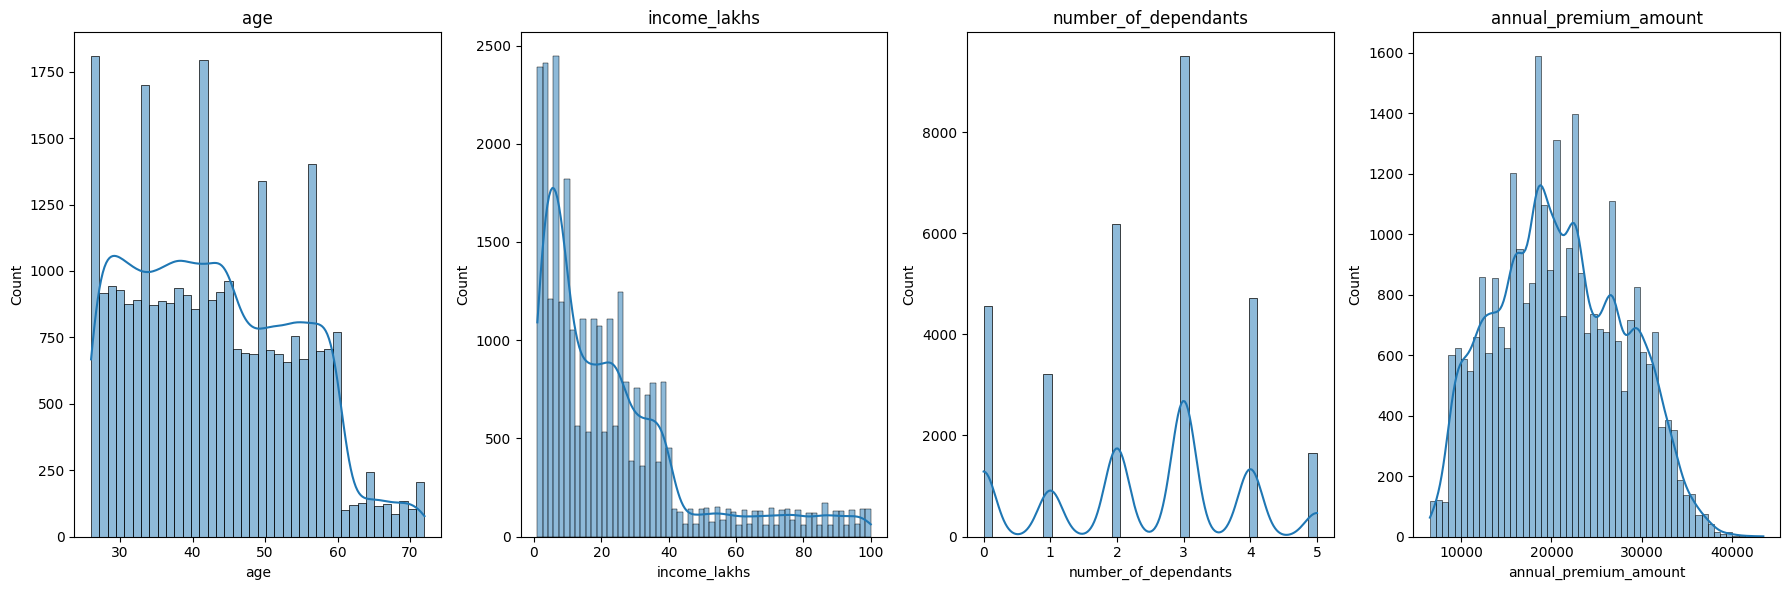

In [21]:
numeric_colums = ['age', 'income_lakhs', 'number_of_dependants','annual_premium_amount']

fig, axes = plt.subplots(1, len(numeric_colums), figsize=(18, 6))  # Adjust figure size as necessary

for ax, column in zip(axes, numeric_colums):
    sns.histplot(x=df2[column],kde=True,ax=ax)
    ax.set_title(f'{column}')
    ax.set_xlabel(column)

plt.tight_layout()  # Adjust layout
plt.show()

## Cleaning categorical data and visualizing it

In [22]:
categorical_features = df2.select_dtypes(include=['str']).columns
categorical_features

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='str')

In [23]:
for feature in categorical_features:
    print(f'{feature}: {df2[feature].unique()}')

gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
region: <StringArray>
['Northwest', 'Southeast', 'Northeast', 'Southwest']
Length: 4, dtype: str
marital_status: <StringArray>
['Unmarried', 'Married']
Length: 2, dtype: str
bmi_category: <StringArray>
['Normal', 'Obesity', 'Overweight', 'Underweight']
Length: 4, dtype: str
smoking_status: <StringArray>
[    'No Smoking',        'Regular',     'Occasional', 'Does Not Smoke',
    'Not Smoking',      'Smoking=0']
Length: 6, dtype: str
employment_status: <StringArray>
['Salaried', 'Self-Employed', 'Freelancer']
Length: 3, dtype: str
income_level: <StringArray>
['<10L', '10L - 25L', '> 40L', '25L - 40L']
Length: 4, dtype: str
medical_history: <StringArray>
[                           'Diabetes',                 'High blood pressure',
                          'No Disease',      'Diabetes & High blood pressure',
                             'Thyroid',                       'Heart disease',
 'High blood pressure & Heart disease',

In [24]:
df2['smoking_status'] = df2['smoking_status'].replace({
    'Smoking=0':'No Smoking',
    'Does Not Smoke':'No Smoking',
    'Not Smoking':'No Smoking'
})

df2.smoking_status.unique()

<StringArray>
['No Smoking', 'Regular', 'Occasional']
Length: 3, dtype: str

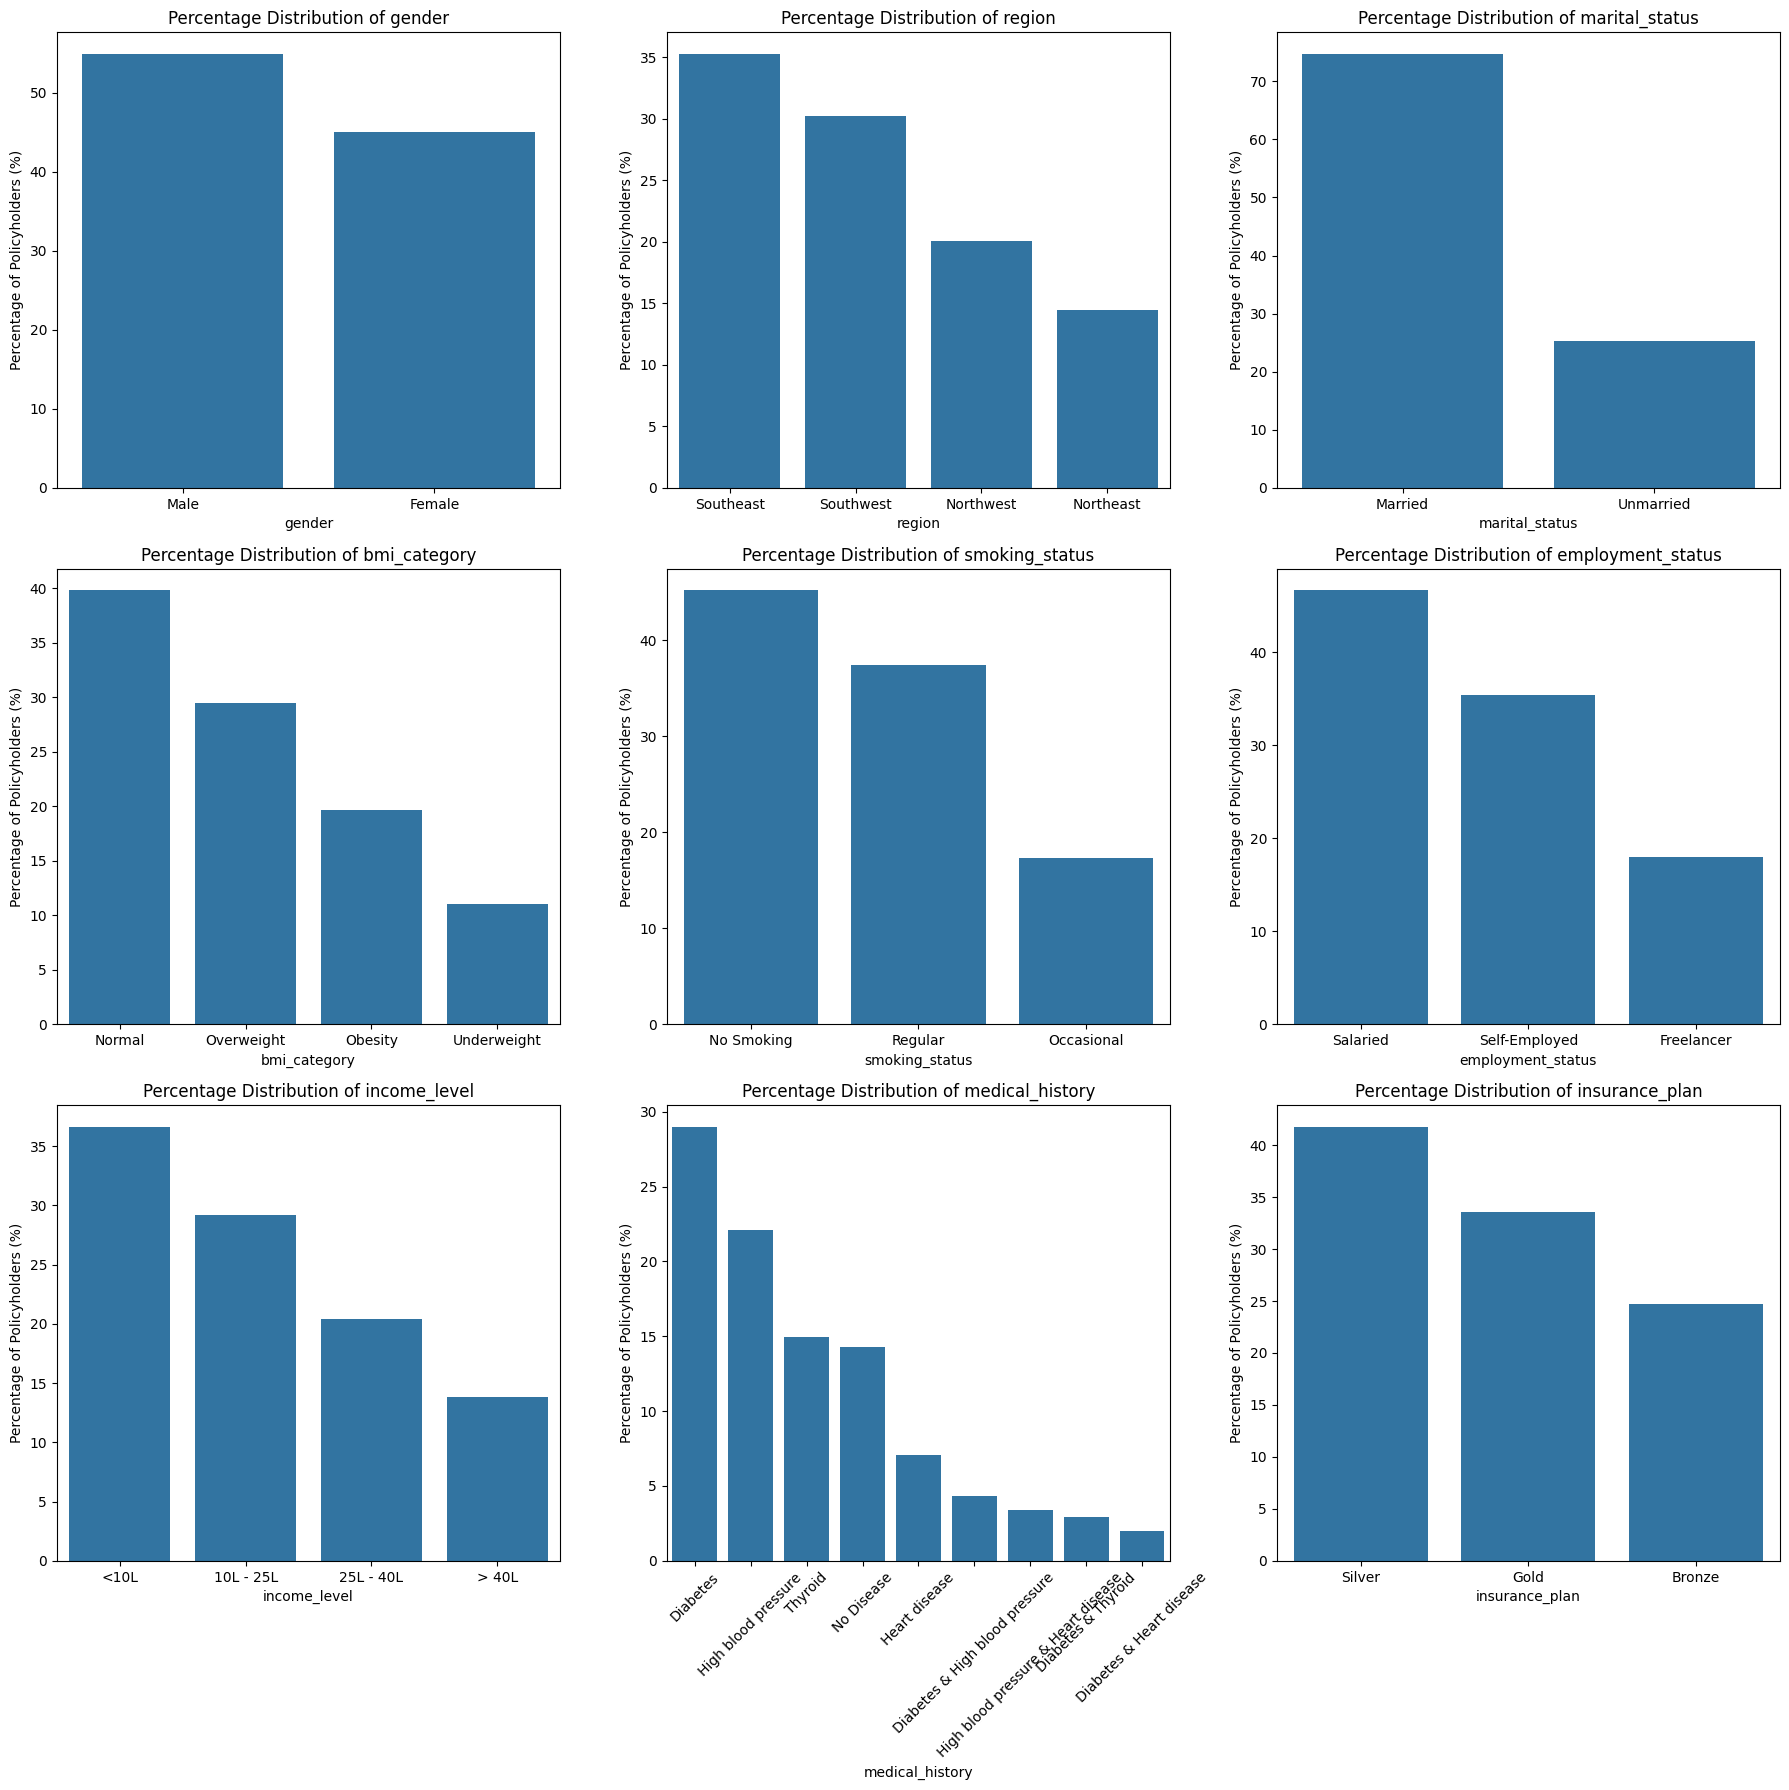

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_features):
    # Calculate the percentage distribution of each category
    category_counts = df2[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    if column == 'medical_history':
        ax.tick_params(axis='x', rotation=45)
    
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

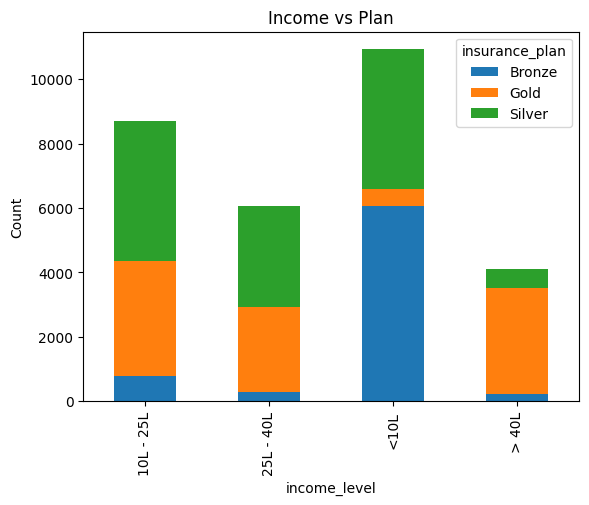

In [26]:
crosstab = pd.crosstab(df2.income_level,df2.insurance_plan)
crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

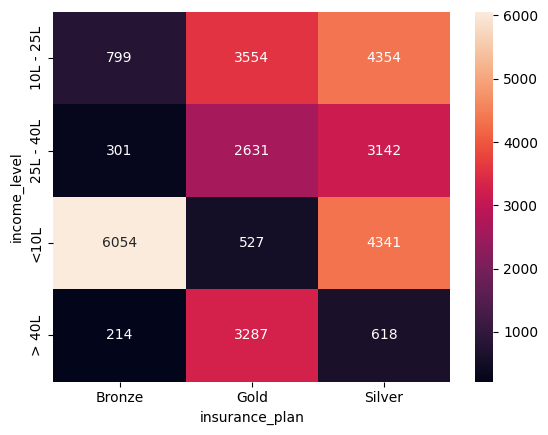

In [27]:
sns.heatmap(crosstab,annot=True,fmt='d')
plt.show()

## Feature Engineering - Calculate risk score for health history

In [28]:
risk_scores = {
    "diabetes": 6,
    "heart disease": 8,
    "high blood pressure":6,
    "thyroid": 5,
    "no disease": 0,
    "none":0
}

df2[['disease_1','disease_2']] = df2['medical_history'].str.split(' & ',expand=True).apply(lambda x: x.str.lower())

df2['disease_1'] = df2['disease_1'].fillna('none')
df2['disease_2'] = df2['disease_2'].fillna('none')

df2['total_risk_score'] = 0

for disease in ['disease_1', 'disease_2']:
    df2['total_risk_score']+= df2[disease].map(risk_scores)

min_score = df2['total_risk_score'].min()
max_score = df2['total_risk_score'].max()

df2['normalised_risk_score'] = (df2['total_risk_score'] - min_score) / (max_score - min_score)
df2.head(1)

,unnamed:_0,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,disease_1,disease_2,total_risk_score,normalised_risk_score
0,0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,1,diabetes,none,6,0.428571


## Feature Engineering - Dropping unwanted columns and creating a new df

In [29]:
df3 = df2.drop(['medical_history','disease_1' , 'disease_2', 'total_risk_score'],axis=1)
df3.head()

,unnamed:_0,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalised_risk_score
0,0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Bronze,9053,1,0.428571
1,1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Bronze,16339,1,0.428571
2,2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,Silver,18164,1,0.428571
3,3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,Gold,20303,1,0.000000
4,5,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Bronze,15610,1,0.428571


## Feature Engineering - mapping maritial_satus column and converting it to numerical values

In [30]:
df3['insurance_plan'] = df3['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
df3.head(1)

,unnamed:_0,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalised_risk_score
0,0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,1,9053,1,0.428571


In [31]:
df3['income_level'] = df3['income_level'].map({'<10L':1, '10L - 25L': 2, '25L - 40L':3, '> 40L':4})
df3.head(1)

,unnamed:_0,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalised_risk_score
0,0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,1,6,1,9053,1,0.428571


In [32]:
nominal_cols = ['gender','region', 'marital_status', 'bmi_category', 'smoking_status', 'employment_status']
df3 = pd.get_dummies(df3, columns=nominal_cols, drop_first=True, dtype=int)
df3.head(3)

,unnamed:_0,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,genetical_risk,normalised_risk_score,gender_Male,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0,26,0,1,6,1,9053,1,0.428571,1,...,0,0,1,0,0,0,0,0,1,0
1,1,29,2,1,6,1,16339,1,0.428571,0,...,1,0,0,1,0,0,0,1,1,0
2,2,49,2,2,20,2,18164,1,0.428571,0,...,0,0,0,0,0,0,0,0,0,1


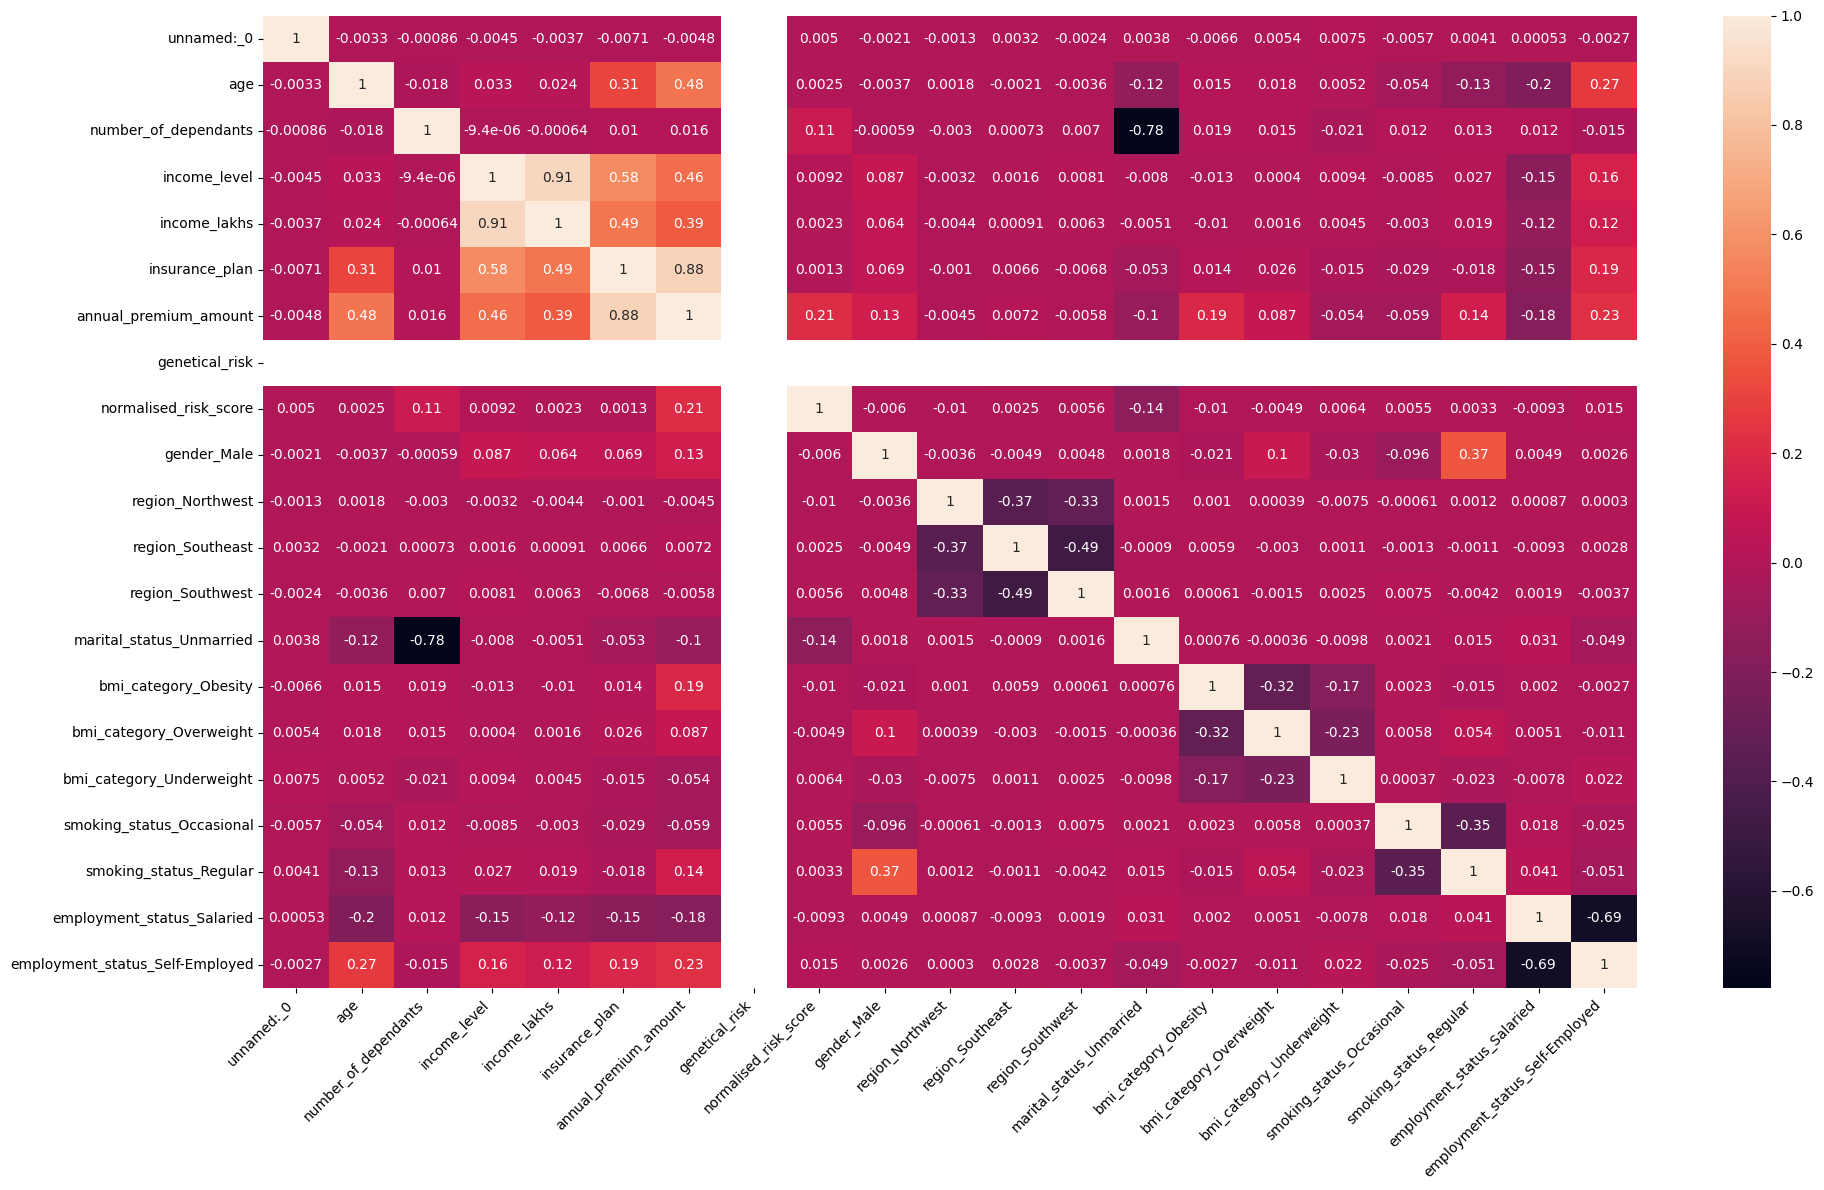

In [33]:
cm = df3.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Feature Engineering - Finding correlation between features using Vif

In [34]:
X = df3.drop('annual_premium_amount',axis=1)
y = df3['annual_premium_amount']

scaler = MinMaxScaler()
columns = ['age','number_of_dependants','income_level','income_lakhs','insurance_plan','genetical_risk']
X[columns] = scaler.fit_transform(X[columns])


In [35]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['column'] = data.columns
    vif_df['score'] = [variance_inflation_factor(data.values,i)for i in range(data.shape[1])]
    return vif_df

In [36]:
calculate_vif(X)

C:\Users\anilj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,column,score
0,unnamed:_0,3.708010
1,age,3.957380
2,number_of_dependants,6.574054
3,income_level,13.890759
4,income_lakhs,11.186315
5,insurance_plan,5.272795
6,genetical_risk,NaN
7,normalised_risk_score,3.847203
8,gender_Male,2.600903
9,region_Northwest,2.143527


In [37]:
X = X.drop('income_level',axis=1)
calculate_vif(X)

C:\Users\anilj\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\regression\linear_model.py:1784: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.uncentered_tss


,column,score
0,unnamed:_0,3.707947
1,age,3.898275
2,number_of_dependants,6.573384
3,income_lakhs,2.679612
4,insurance_plan,4.576402
5,genetical_risk,NaN
6,normalised_risk_score,3.845003
7,gender_Male,2.593274
8,region_Northwest,2.142869
9,region_Southeast,3.015344


## Model Training

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

print("x train: ",X_train.shape)
print("x test: ",X_test.shape)
print("y train: ",y_train.shape)
print("y test: ",y_test.shape)

x train:  (20875, 19)
x test:  (8947, 19)
y train:  (20875,)
y test:  (8947,)


In [39]:
model_lr = LinearRegression()
model_lr.fit(X_train,y_train)
score = model_lr.score(X_test,y_test)
score

0.953841128576026

In [40]:
model_rd = Ridge()
model_rd.fit(X_train,y_train)
score = model_rd.score(X_test,y_test)
score

0.9538420204822269

In [41]:
model_xgb = XGBRegressor()
model_xgb.fit(X_train,y_train)
score = model_xgb.score(X_test,y_test)
score

0.9979413747787476

In [42]:
param_grid = {
    'n_estimators': [20, 40, 50],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
}
random_search = RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_
best_model = random_search.best_estimator_
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

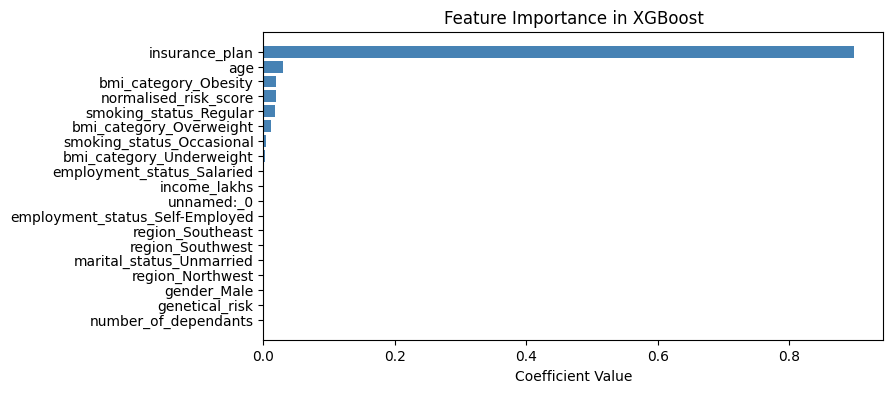

In [43]:
feature_importance = best_model.feature_importances_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in XGBoost')
plt.show()

In [44]:
y_pred = best_model.predict(X_test)
residual = y_pred - y_test
residual_pct = residual*100/y_test
result_df = pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residual,
    'diff_pct':residual_pct
})
result_df.head()

,actual,predicted,diff,diff_pct
19713,26895,26691.470703,-203.529297,-0.756755
14750,22734,22650.759766,-83.240234,-0.366149
19932,21198,21581.896484,383.896484,1.811003
29643,9100,9425.934570,325.934570,3.581699
17076,26434,26691.470703,257.470703,0.974013


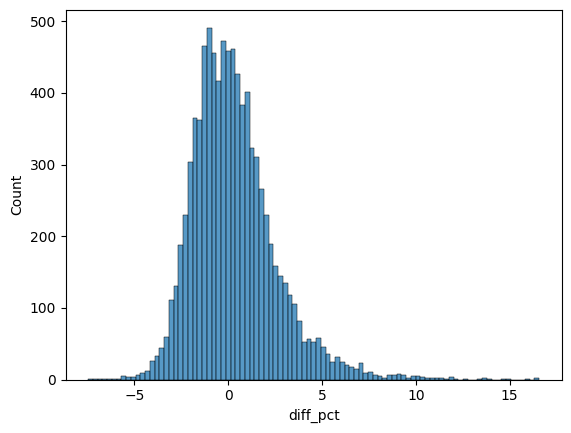

In [45]:
sns.histplot(result_df,x='diff_pct')
plt.show()

In [46]:
pct_threshold = 10
extreme_result_df  = result_df[abs(result_df.diff_pct)>pct_threshold]
extreme_result_df

,actual,predicted,diff,diff_pct
14286,6845,7621.264648,776.264648,11.340608
27518,8502,9425.934570,923.934570,10.867261
9285,6872,7621.264648,749.264648,10.903153
7547,6538,7621.264648,1083.264648,16.568747
21910,6651,7621.264648,970.264648,14.588252
12189,6571,7621.264648,1050.264648,15.983331
21141,10722,11841.493164,1119.493164,10.441085
16263,8206,9063.518555,857.518555,10.449897
8216,6635,7621.264648,986.264648,14.864576
13973,10583,11841.493164,1258.493164,11.891649


In [47]:
extreme_error_pct = extreme_result_df.shape[0]*100/result_df.shape[0]
extreme_error_pct

0.32413099362914943

In [48]:
result_df[abs(result_df.diff_pct)>50]

,actual,predicted,diff,diff_pct


In [49]:
extreme_error_df = X_test.loc[extreme_result_df.index]
extreme_error_df.head()

,unnamed:_0,age,number_of_dependants,income_lakhs,insurance_plan,genetical_risk,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
14286,23963,0.021739,0.6,0.050505,0.0,0.0,0.000000,1,1,0,0,1,0,0,0,0,0,1,0
27518,45953,0.304348,0.6,0.080808,0.0,0.0,0.357143,1,1,0,0,0,0,0,0,0,0,0,1
9285,15609,0.326087,0.6,0.010101,0.0,0.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
7547,12724,0.347826,0.2,0.080808,0.0,0.0,0.000000,1,0,1,0,1,0,0,0,0,0,1,0
21910,36664,0.043478,0.6,0.020202,0.0,0.0,0.000000,1,0,1,0,0,0,0,0,0,0,0,0


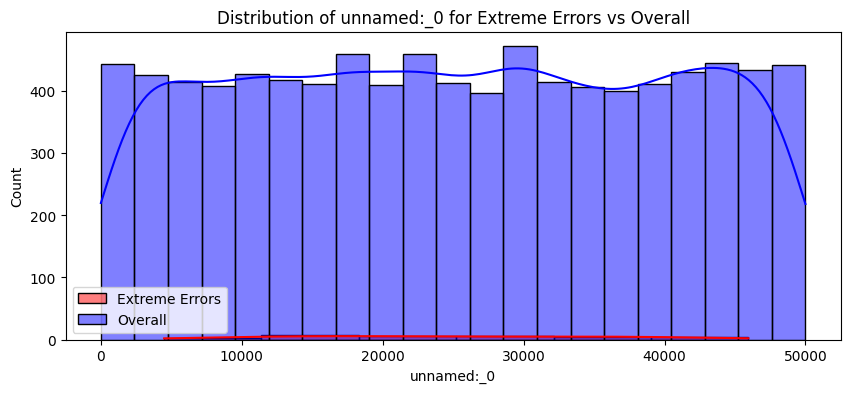

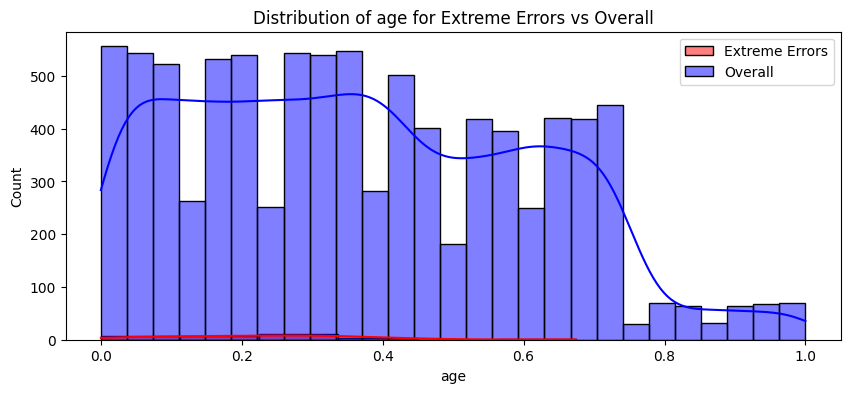

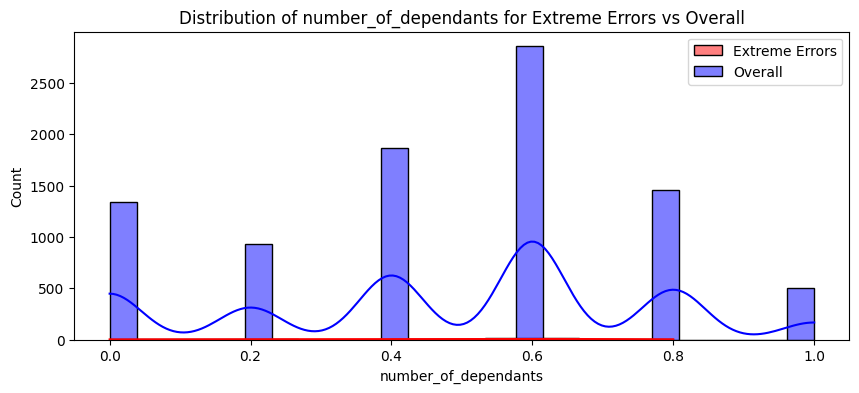

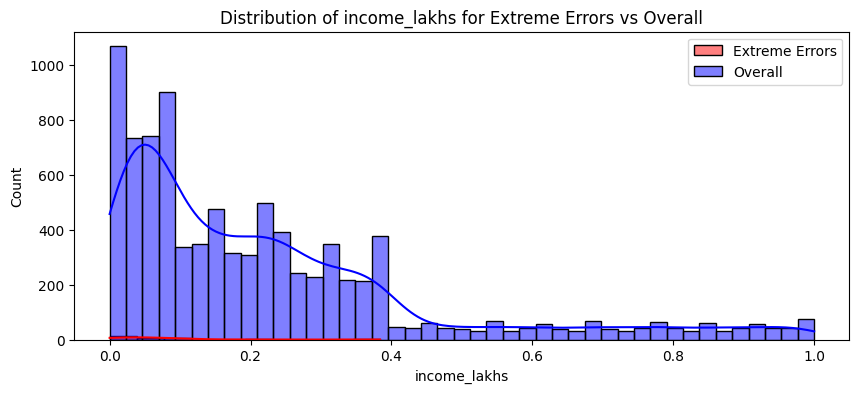

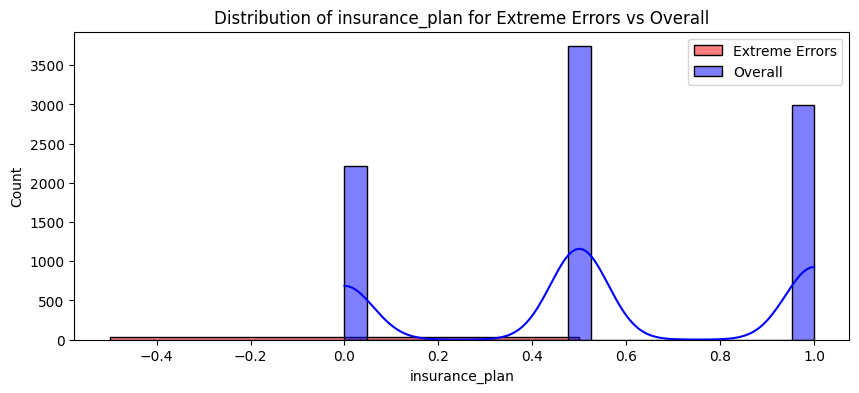

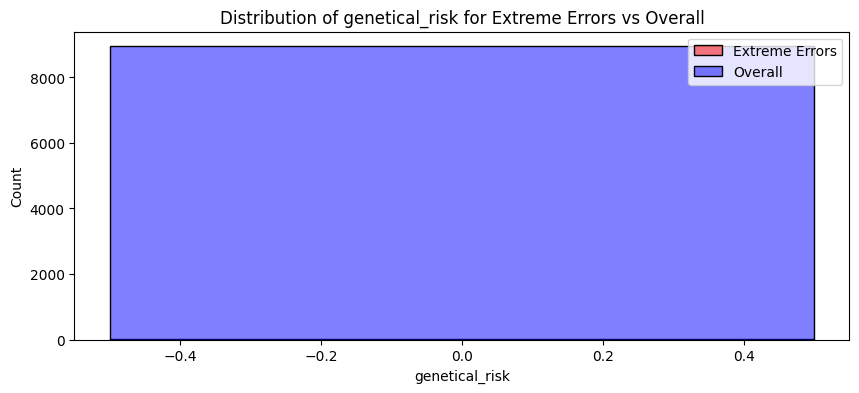

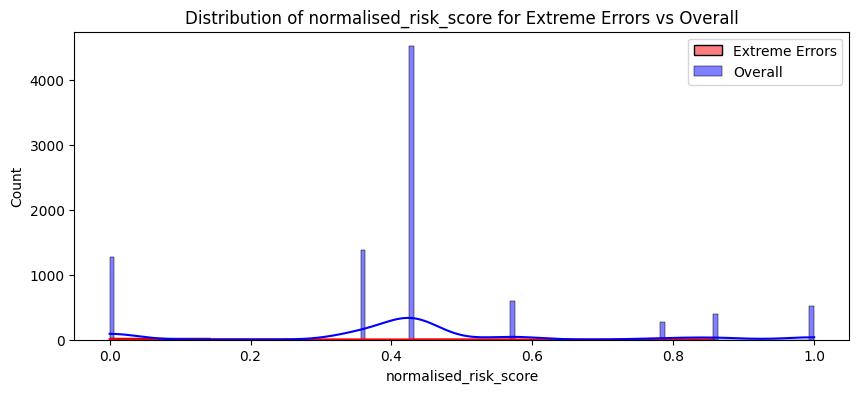

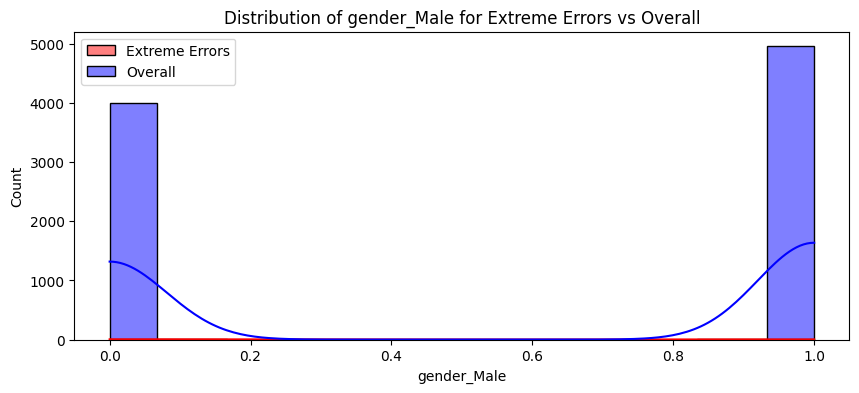

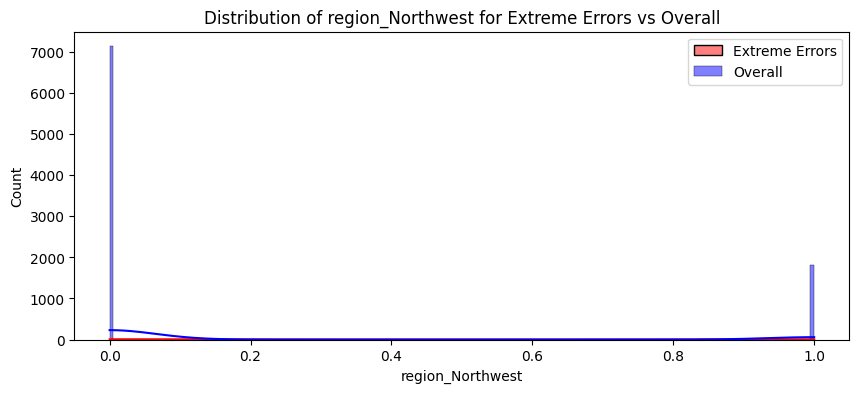

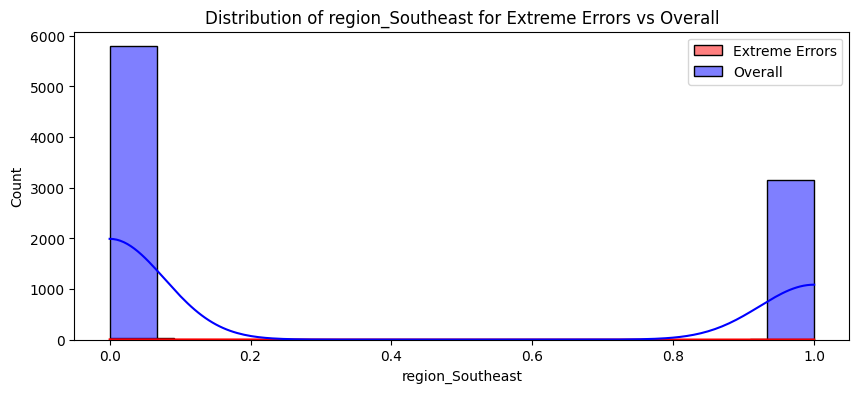

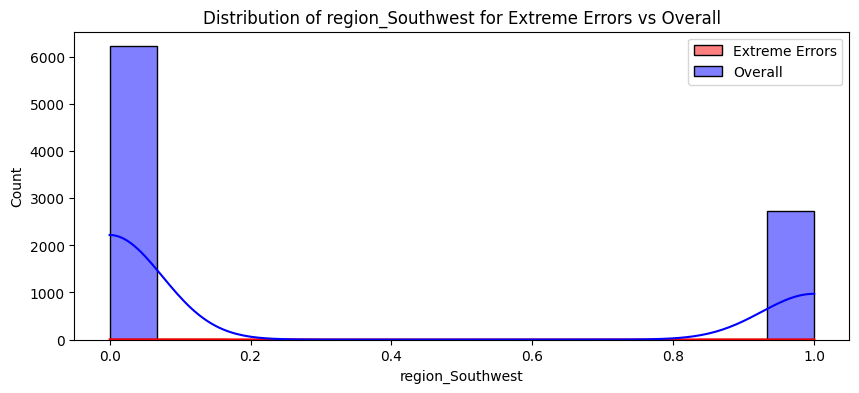

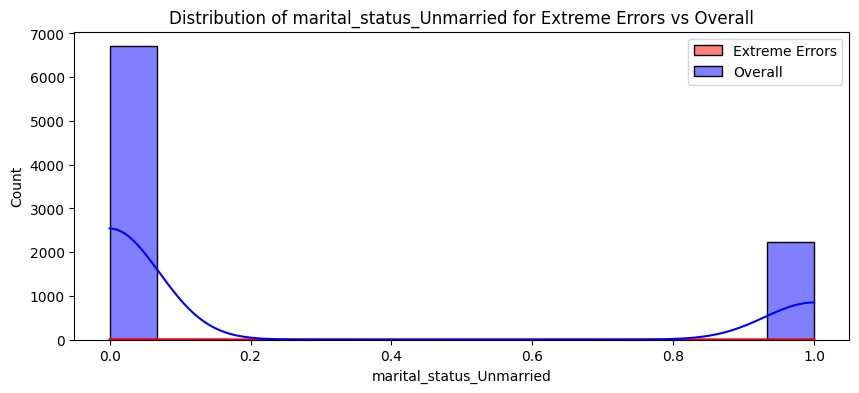

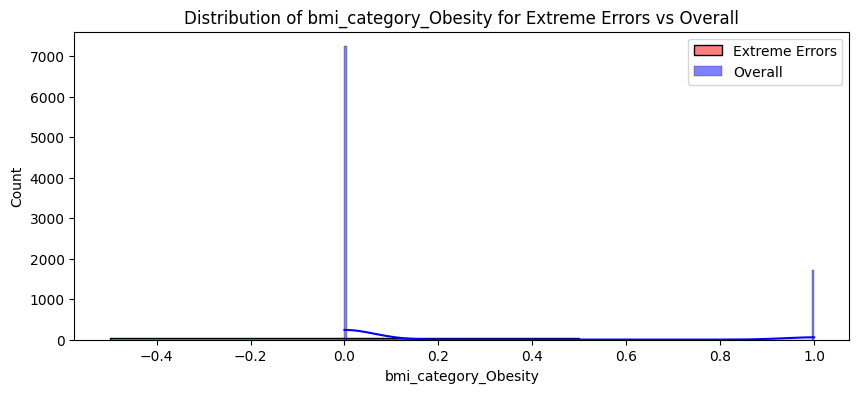

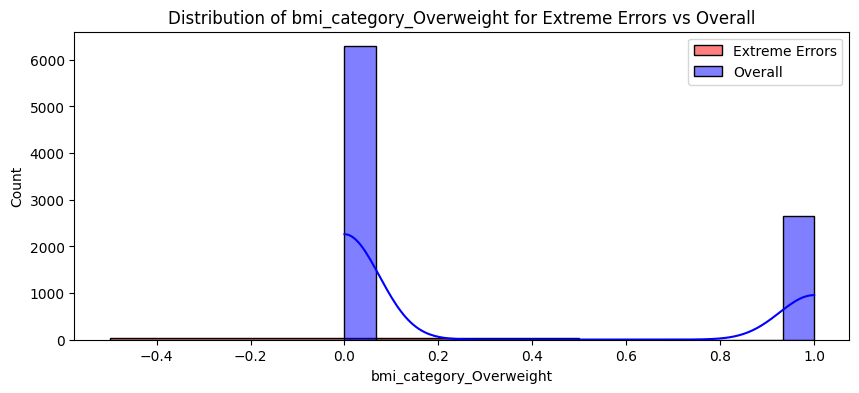

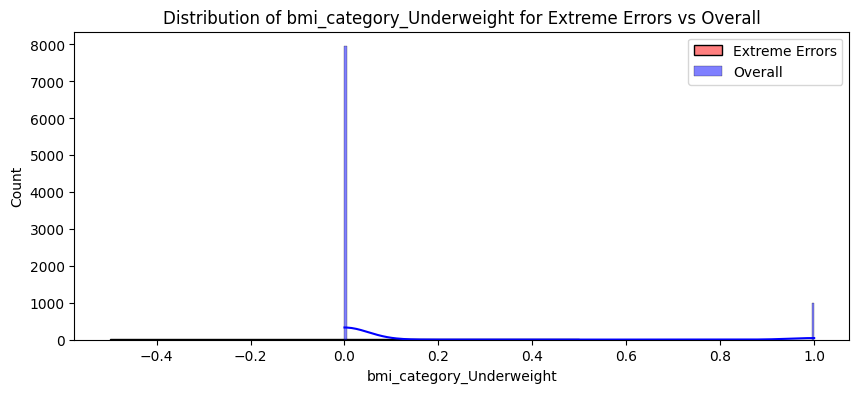

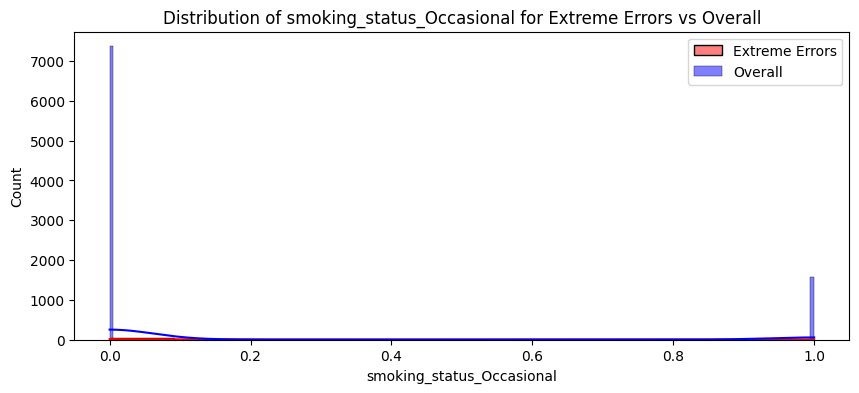

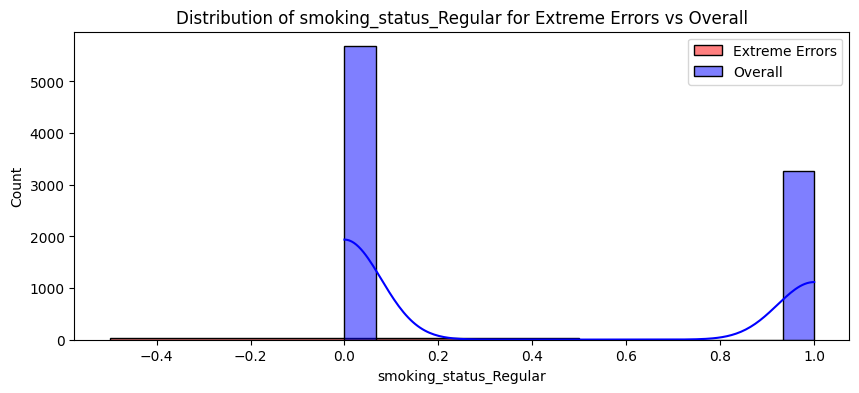

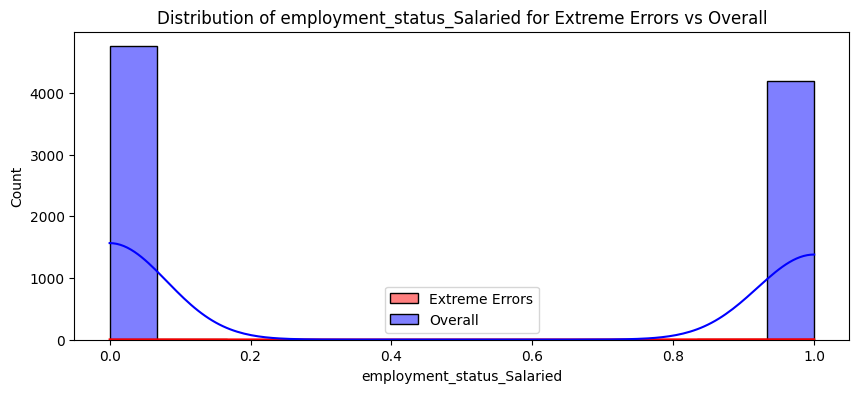

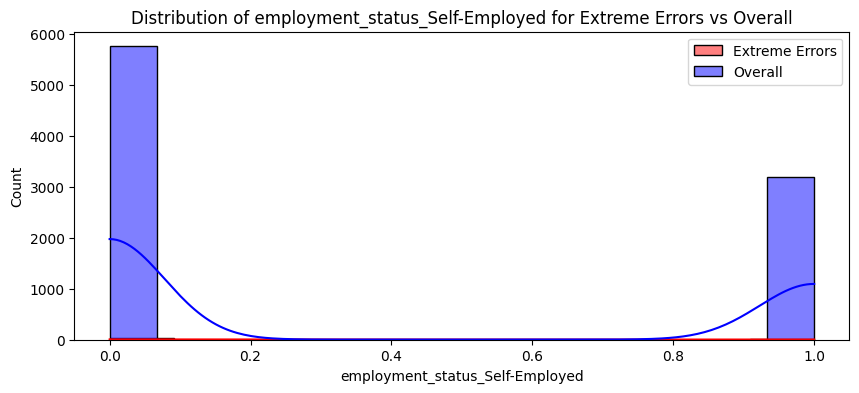

In [50]:
for feature in X_test.columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(extreme_error_df[feature], color='red', label='Extreme Errors', kde=True)
    sns.histplot(X_test[feature], color='blue', label='Overall', alpha=0.5, kde=True)
    plt.legend()
    plt.title(f'Distribution of {feature} for Extreme Errors vs Overall')
    plt.show()

In [51]:
reverse_df = pd.DataFrame()
extreme_error_df['income_level'] = None
reverse_df[columns] = scaler.inverse_transform(extreme_error_df[columns])
reverse_df.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk
0,27.0,3.0,NaN,6.0,1.0,1.0
1,40.0,3.0,NaN,9.0,1.0,1.0
2,41.0,3.0,NaN,2.0,1.0,1.0
3,42.0,1.0,NaN,9.0,1.0,1.0
4,28.0,3.0,NaN,3.0,1.0,1.0


In [52]:
reverse_df.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,genetical_risk
count,29.000000,29.000000,0.0,29.000000,29.0,29.0
mean,36.586207,2.241379,NaN,6.862069,1.0,1.0
std,6.811321,1.184880,NaN,7.619168,0.0,0.0
min,26.000000,0.000000,NaN,1.000000,1.0,1.0
25%,32.000000,1.000000,NaN,3.000000,1.0,1.0
50%,37.000000,3.000000,NaN,5.000000,1.0,1.0
75%,40.000000,3.000000,NaN,9.000000,1.0,1.0
max,57.000000,4.000000,NaN,39.000000,1.0,1.0


<Axes: xlabel='age', ylabel='Count'>

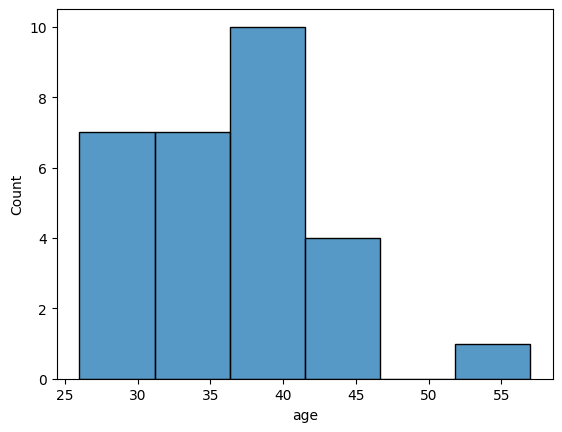

In [53]:
sns.histplot(reverse_df.age)

In [54]:
reverse_df.age.quantile(0.97)

np.float64(47.760000000000005)

In [ ]:
dump(best_model,'artifacts/rest_model.joblib')
scaler_with_col = {
    'scaler':scaler,
    'columns': columns
}
dump(scaler_with_col,'artifacts/rest_model_scaler.joblib')